In [3]:
%load_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import jax
import seaborn as sns

jax.config.update('jax_platforms', 'cpu')

plt.rcParams['font.family'] = 'Helvetica Light'

from behavioral_plotting import (
    plot_session,
    load_odor_site_df,
    plot_patch_statistics_per_session,
    plot_patch_statistics_across_dfs,
    plot_patch_statistics,
    plot_multi_df_accuracy_heatmap,
    plot_leave_probabilities,
    append_index_phase,
    plot_grouped_mean_std,
    plot_stop_fraction,
    plot_first_patch_rewards_vs_other_prefactors,
    plot_rewards_by_patch_sequence,
    odor_colors,
)
from aux_funcs import format_plot
from nb_analysis_tools import *

In [3]:
# had to clear the font cache to get the Helvetica Light font to work.
# If you see a warning about missing fonts, run this cell and restart the kernel.

# import matplotlib as mpl
# import shutil, os

# # Find and delete the font cache
# cache_dir = mpl.get_cachedir()
# print(f"Cache dir: {cache_dir}")

# # Delete cache files
# for f in os.listdir(cache_dir):
#     if f.endswith('.json') or f.endswith('.cache'):
#         os.remove(os.path.join(cache_dir, f))
#         print(f"Deleted: {f}")

# print("Done — restart the kernel now")

In [4]:
from pathlib import Path

def find_trajectories(results_dir):
    """Return sorted list of traj_*.pkl path strings under results_dir."""
    root = Path(results_dir)
    return sorted(str(p) for p in root.rglob('traj_*.pkl'))

In [5]:
CURRICULUM_TRAINED_NETWORKS_V2 = find_trajectories(
    '../../../results/fixed_exp_gru_initial_prob_offset_low_becomes_high'
)
print(f'V2: {len(CURRICULUM_TRAINED_NETWORKS_V2)} trajectories')

V2: 30 trajectories


In [6]:
CURRICULUM_TRAINED_NETWORKS_HIGH_BECOMES_LOW = find_trajectories(
    '../../../results/fixed_exp_gru_initial_prob_offset_high_becomes_low'
)
print(f'high_becomes_low: {len(CURRICULUM_TRAINED_NETWORKS_HIGH_BECOMES_LOW)} trajectories')

high_becomes_low: 30 trajectories


In [21]:
CURRICULUM_TRAINED_NETWORKS_LOW_BECOMES_HIGH_SLOW = find_trajectories(
    '../../../results/fixed_exp_gru_initial_prob_offset_low_becomes_high_lr_1e-5'
)
print(f'low_becomes_high_slow: {len(CURRICULUM_TRAINED_NETWORKS_LOW_BECOMES_HIGH_SLOW)} trajectories')

low_becomes_high_slow: 30 trajectories


## Behavioral traces

[0.15360713 0.1667553  0.5713192 ]


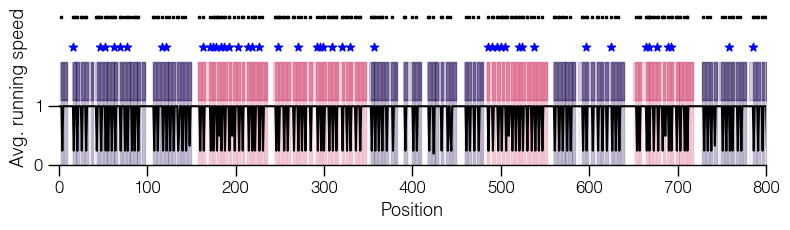

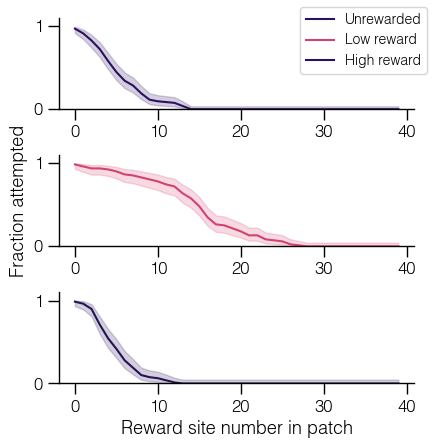

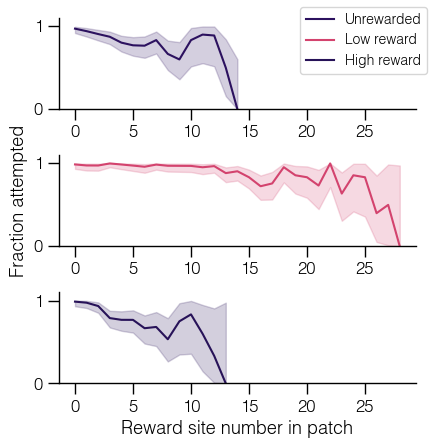

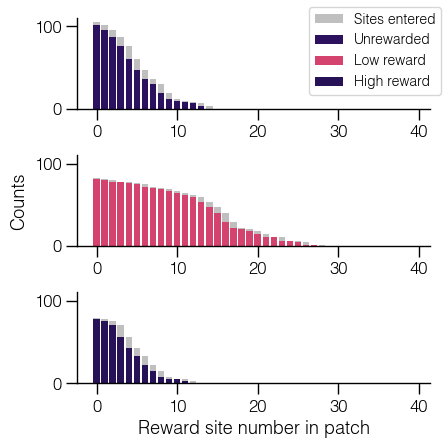

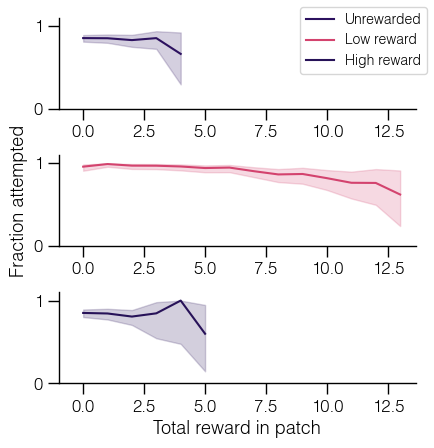

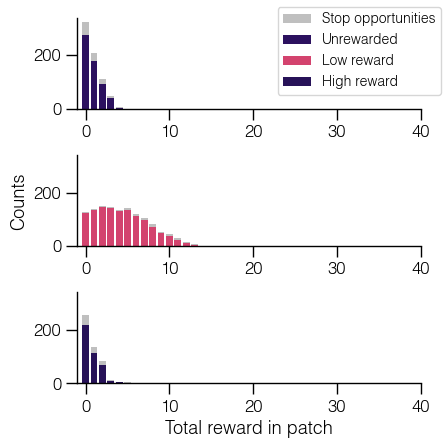

In [ ]:
for i, data_path in enumerate(CURRICULUM_TRAINED_NETWORKS_V2):
    plot_session(
        data_path,
        session_idx=0,
        xlim=(0, 800),
        max_reward_param=40,
        max_reward_sites=30,
        use_fixed_colors=False,
        color_by_reward_param=False
    )

## Odor site data loading

In [7]:
dfs = [
    load_odor_site_df(x, nn_num=nn_num, brief=True)
    for nn_num, x in enumerate(CURRICULUM_TRAINED_NETWORKS_V2)
]

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries ge

In [8]:
dfs_high_becomes_low = [
    load_odor_site_df(x, nn_num=nn_num, brief=True)
    for nn_num, x in enumerate(CURRICULUM_TRAINED_NETWORKS_HIGH_BECOMES_LOW)
]

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries ge

In [22]:
dfs_low_becomes_high_slow = [
    load_odor_site_df(x, nn_num=nn_num, brief=True)
    for nn_num, x in enumerate(CURRICULUM_TRAINED_NETWORKS_LOW_BECOMES_HIGH_SLOW)
]

Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries generated
Session data loaded
Session summaries ge

## Mean rewards harvested and probability of reward at leave across sessions

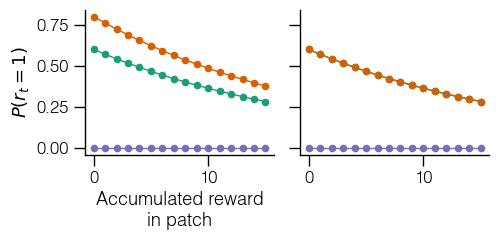

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharex=True, sharey=True)

x = np.arange(16)   # 0 through 20

# ── Exponential decay curves ──────────────────────────────────────────────
prefactors  = [0,  0.6,  0.8]   # one per curve
decay_rates = [1,  1/20,  1/20]   # one per curve

for (prefactor, decay_rate, color) in zip(prefactors, decay_rates, odor_colors):
    y = prefactor * np.exp(-decay_rate * x)
    axes[0].plot(x, y, color=color, lw=1)
    axes[0].scatter(x, y, color=color, s=20)
axes[0].set_xlabel('Accumulated reward\nin patch')
axes[0].set_ylabel(r'$P(r_t=1)$')

# ── Exponential decay curves ──────────────────────────────────────────────
prefactors  = [0,  0.6,  0.6]   # one per curve
decay_rates = [1,  1/20,  1/20]   # one per curve

for (prefactor, decay_rate, color) in zip(prefactors, decay_rates, odor_colors):
    y = prefactor * np.exp(-decay_rate * x)
    axes[1].plot(x, y, color=color, lw=1)
    axes[1].scatter(x, y, color=color, s=20)


format_plot(axes)
plt.tight_layout()
plt.show()

### High becomes low

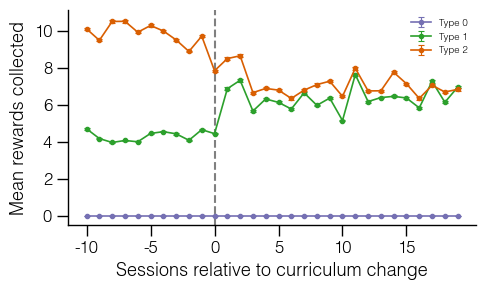

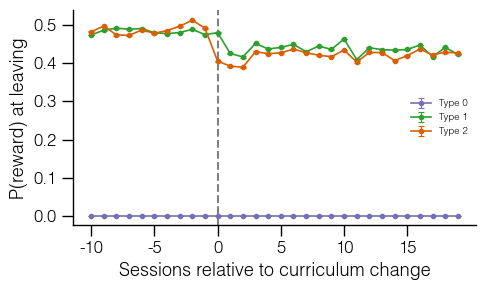

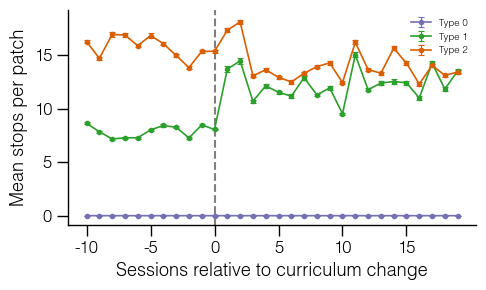

In [11]:
fig1, ax1, fig2, ax2, fig3, ax3 = plot_patch_statistics_across_dfs(
    dfs_high_becomes_low,
    # xticks=np.arange(5) * 5,
    # xticklabels=[f'{s}' for s in np.arange(500, 701, 50)],
)
for ax in [ax1, ax2, ax3]:
    ax.axvline(10, color='grey', ls='--')
    ax.set_xticks(np.arange(0, len(dfs_high_becomes_low), 5))
    ax.set_xticklabels([f'{s}' for s in np.arange(0, len(dfs_high_becomes_low), 5) - 10])
    ax.set_xlabel('Sessions relative to curriculum change')
plt.show(fig1)
plt.close(fig1)
plt.show(fig2)
plt.close(fig2)
plt.show(fig3)
plt.close(fig3)

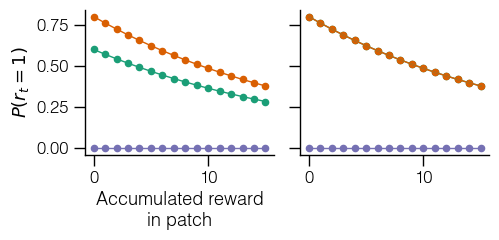

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharex=True, sharey=True)

x = np.arange(16)   # 0 through 20

# ── Exponential decay curves ──────────────────────────────────────────────
prefactors  = [0,  0.6,  0.8]   # one per curve
decay_rates = [1,  1/20,  1/20]   # one per curve

for (prefactor, decay_rate, color) in zip(prefactors, decay_rates, odor_colors):
    y = prefactor * np.exp(-decay_rate * x)
    axes[0].plot(x, y, color=color, lw=1)
    axes[0].scatter(x, y, color=color, s=20)
axes[0].set_xlabel('Accumulated reward\nin patch')
axes[0].set_ylabel(r'$P(r_t=1)$')

# ── Exponential decay curves ──────────────────────────────────────────────
prefactors  = [0,  0.8,  0.8]   # one per curve
decay_rates = [1,  1/20,  1/20]   # one per curve

for (prefactor, decay_rate, color) in zip(prefactors, decay_rates, odor_colors):
    y = prefactor * np.exp(-decay_rate * x)
    axes[1].plot(x, y, color=color, lw=1)
    axes[1].scatter(x, y, color=color, s=20)


format_plot(axes)
plt.tight_layout()
plt.show()

### Low becomes high

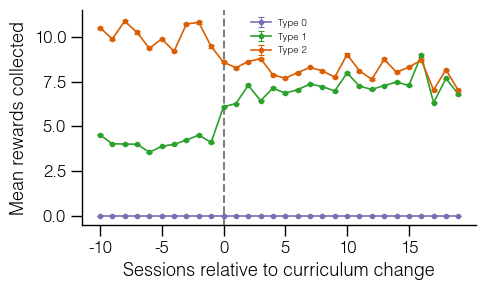

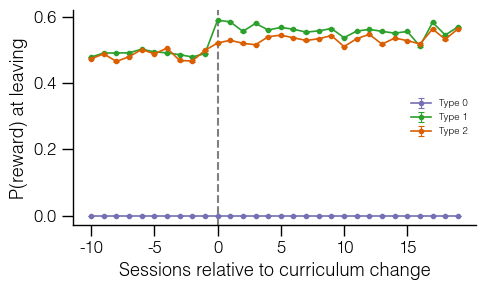

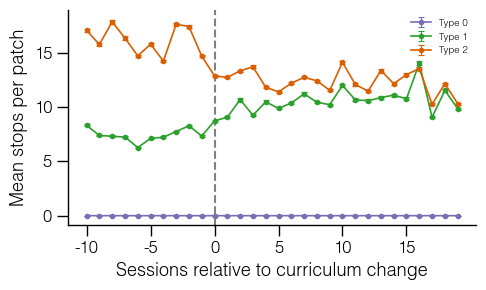

In [12]:
fig1, ax1, fig2, ax2, fig3, ax3 = plot_patch_statistics_across_dfs(
    dfs,
    # xticks=np.arange(5) * 5,
    # xticklabels=[f'{s}' for s in np.arange(500, 701, 50)],
)
for ax in [ax1, ax2, ax3]:
    ax.axvline(10, color='grey', ls='--')
    ax.set_xticks(np.arange(0, len(dfs), 5))
    ax.set_xticklabels([f'{s}' for s in np.arange(0, len(dfs), 5) - 10])
    ax.set_xlabel('Sessions relative to curriculum change')
plt.show(fig1)
plt.close(fig1)
plt.show(fig2)
plt.close(fig2)
plt.show(fig3)
plt.close(fig3)

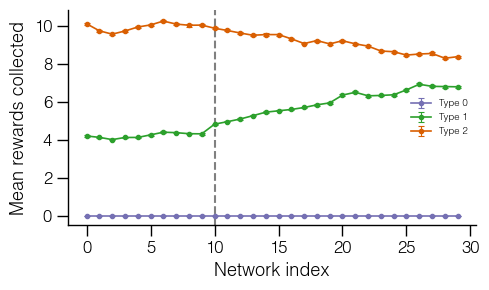

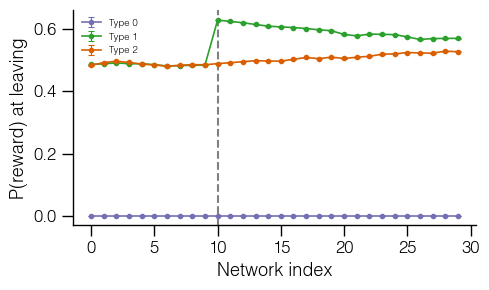

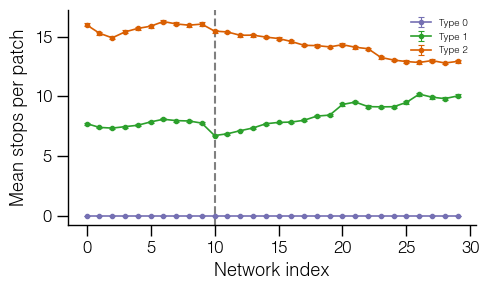

In [26]:
fig1, ax1, fig2, ax2, fig3, ax3 = plot_patch_statistics_across_dfs(
    dfs_low_becomes_high_slow,
    # xticks=np.arange(5) * 5,
    # xticklabels=[f'{s}' for s in np.arange(500, 701, 50)],
)
for ax in [ax1, ax2, ax3]:
    ax.axvline(10, color='grey', ls='--')
plt.show(fig1)
plt.close(fig1)
plt.show(fig2)
plt.close(fig2)
plt.show(fig3)
plt.close(fig3)

In [ ]:
for df in dfs:
    plot_patch_statistics_per_session(
        df,
        ylim_right=[0, 1.],
    )

## Accumulated reward against consecutive failures

In [27]:
for df in dfs:
    plot_stop_fraction(
        df,
        'consecutive_misses',
        'rewards_seen_in_patch',
        condition=lambda d: d[d['patch_type'] > 0],
        invert_y=True,
        figsize=(5, 5),
        reverse=True,
        xlabel='Consecutive Failures',
        ylabel='Cumulative Rewards',
        min_n=5,
    )
None

KeyError: 'consecutive_misses'